In [6]:
import matplotlib.pyplot as plt
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

In [7]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam
)

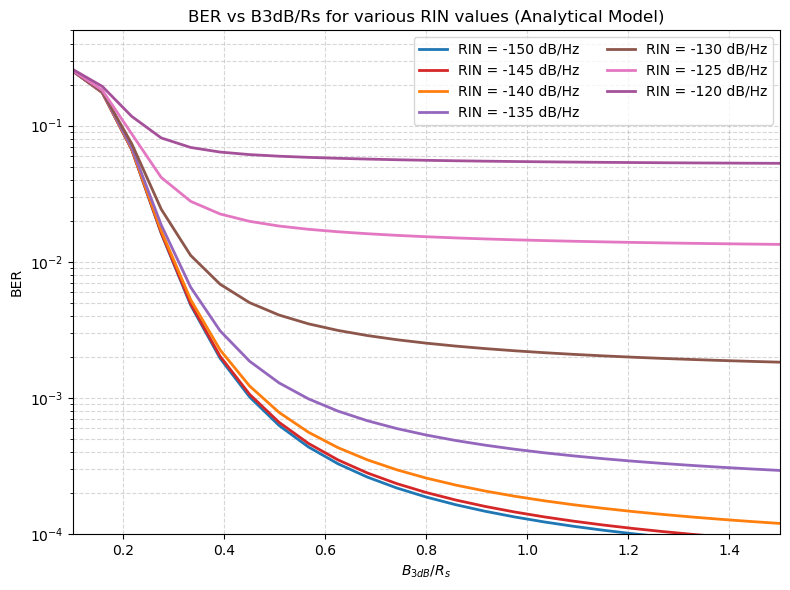

In [ ]:
# 1. Parâmetros do Sistema (Baseado na Fig 4b)
Rs = 56e9                  # 56 GBaud
pTx_dBm = 0                # Potência transmitida (0 dBm)
pTx_W = 10**(pTx_dBm / 10) * 1e-3
ER = 12                    # Extinction Ratio (12 dB)
M = 4                      # Modulação 4-PAM
R = 1                      # Responsividade (A/W)
N0 = 2e-19                 # Ruído térmico (W^2/Hz)
G = 1                      # Ganho do Fotodiodo (PIN = 1)
F = 1                      # Fator de Excesso de Ruído (PIN = 1)

# Cálculo da OMA_outer usando a função do arquivo (espera mW, retorna mW)
OMA_outer_mW = calculate_oma_outer(pTx_W * 1e3, ER)
OMA_outer_W = OMA_outer_mW * 1e-3

# Setup do vetor de frequências
SIM_N = 2048
SIM_fmax = 4 * Rs 
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)

# Formato do pulso (Retangular)
Tb = 1 / Rs
Pulse = np.sinc(Tb * f)
HT_f = Pulse # O módulo ao quadrado será aplicado internamente por get_spectral_snr

# 2. Níveis de Potência e Heurística dos Olhos
alpha_k = np.array([-3, -1, 1, 3])
P_levels = pTx_W + (OMA_outer_W / (2 * (M - 1))) * alpha_k

# Potência média individual dos 3 olhos internos
P_eye = [
    (P_levels[0] + P_levels[1]) / 2, # Olho inferior
    (P_levels[1] + P_levels[2]) / 2, # Olho central
    (P_levels[2] + P_levels[3]) / 2  # Olho superior
]

# 3. Varredura de Parâmetros (RIN & Banda)
RIN_values_dB_Hz = [-150, -145, -140, -135, -130, -125, -120]
bw_ratios = np.linspace(0.1, 1.5, 25)

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#d62728', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#a5519a']

for rin_db, color in zip(RIN_values_dB_Hz, colors):
    ber_curve = []
    
    for bw_ratio in bw_ratios:
        B_3dB = bw_ratio * Rs
        
        # Filtro do canal usando a função superGauss
        H_ch = superGauss(f, n=1, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        ber_eyes = []
        
        # Iteração da heurística sobre os 3 olhos do sinal 4-PAM
# Iteração da heurística sobre os 3 olhos do sinal 4-PAM
        for p_avg_eye in P_eye:
            
            # 1. Obtenção das PSDs usando as funções customizadas
            S_RIN_array = calc_S_RIN(p_avg_eye**2, rin_db, f)
            S_shot_array = calc_S_shot(p_avg_eye, G, F, R, f)
            S_th_array = calc_S_th(N0, f)
            
            # 2. Consolidação do ruído total (Desabilitando o ADC)
            S_N_total = calc_S_N(S_RIN_array, S_shot_array, S_th_array, np.zeros_like(f), H_ch_sq, enable_S_ADC=False)
            
            # 3. SNR Espectral
            SNR_f = get_spectral_snr(f, OMA_outer_W, Rs, HT_f, H_ch, S_N_total)
            
            # 4. Dobramento da SNR (Aliasing do ADC)
            SNR_folded = SNR_Folding(SNR_f, f, mu=3, Rs=Rs)
            
            # 5. Integração do equalizador FFE
            SNR_FFE_linear = SNR_FFE(SNR_folded, f, Rs)
            
            # 6. Conversão SNR -> BER para o olho isolado. 
            # CORREÇÃO: Usar a equação (11) do artigo com M=4 (M=M) e não M=2!
            ber_eye = ber_from_snr_m_pam(SNR_FFE_linear, M=M)
            ber_eyes.append(ber_eye)
            
        # 7. BER Global é a média da BER dos 3 valores obtidos usando a Eq. (11)
        ber_curve.append(np.mean(ber_eyes))
        
    plt.semilogy(bw_ratios, ber_curve, color=color, linewidth=2, label=f'RIN = {rin_db} dB/Hz')

# 4. Formatação do Gráfico
plt.title('BER vs B3dB/Rs for various RIN values (Analytical Model)')
plt.xlabel('$B_{3dB}/R_s$')
plt.ylabel('BER')
plt.ylim(1e-4, 0.5)
plt.xlim(0.1, 1.5)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Iniciando varredura analítica. Isso pode levar alguns segundos...


C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_41544\715025588.py:62: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_41544\715025588.py:85: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


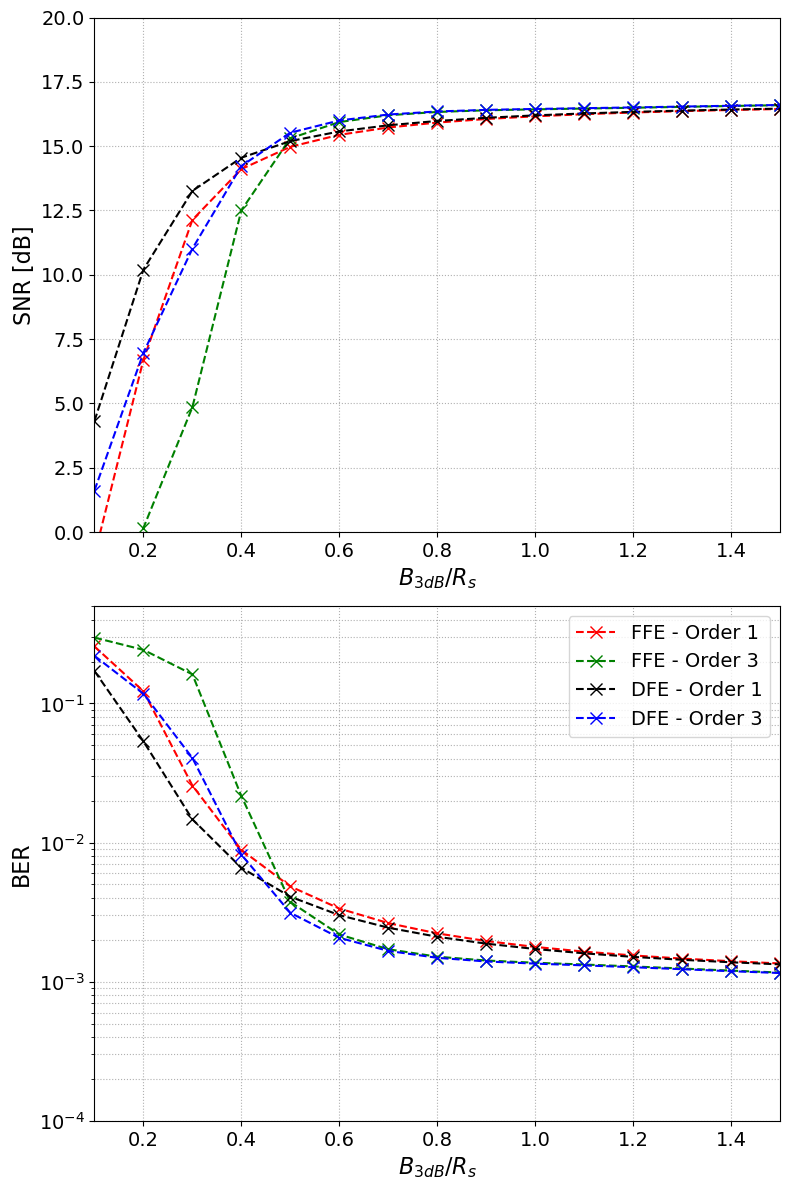

In [9]:


# PARÂMETROS GLOBAIS E CONSTANTES
Rs = 25e9
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 10**(6/10)
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = 2 * pTx_W * ((ER - 1) / (ER + 1))
niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)

# Resposta do Pulso e Ruídos Fixos (Não dependem do filtro do canal)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) # Assumindo PIN sem ganho extra

#  PREPARAÇÃO DOS LOOPS (VARREDURA)
b_rs_ratios = np.arange(0.1, 1.6, 0.1) # Vai de 0.1 até 1.5
orders = [1, 3]

# Dicionários para armazenar os resultados para cada ordem
results = {
    1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
    3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}
}

print("Iniciando varredura analítica. Isso pode levar alguns segundos...")

# LOOP PRINCIPAL
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        
        # 1. Resposta do Canal
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        # 2. Ruído Total Global (Para plotar a curva de SNR Global)
        S_RIN_global = calc_S_RIN(pTx_mean_squared, RIN, f)
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, H_ch_sq, 10, False)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        # 4. Folding e Integrais Globais (Para o Gráfico de SNR)
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        # 5. Loop Heurístico "Olho-por-Olho" (Para o Gráfico de BER)
        ber_ffe_eyes = []
        ber_dfe_eyes = []
        
        for i in range(M - 1):
            # Recalcula o RIN focado na potência dos 2 níveis que formam ESTE olho
            pTx_eye_squared = np.mean(Ps2[i : i+2]**2)
            S_RIN_eye = calc_S_RIN(pTx_eye_squared, RIN, f)
            S_N_eye = calc_S_N(S_RIN_eye, S_shot, S_th, H_ch_sq, 10, False)
            
            # SNR e Folding deste olho
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            # Equalizadores
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        # A BER final é a média das BERs dos 3 olhos
        results[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

# PLOTAGEM DOS GRÁFICOS (Idêntico ao Artigo)
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results[1]['snr_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[0].plot(b_rs_ratios, results[1]['snr_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[0].set_ylabel('SNR [dB]', fontsize=16)
axs[0].set_ylim(0, 20)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].tick_params(axis='both', labelsize=14)

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results[1]['ber_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[1].semilogy(b_rs_ratios, results[1]['ber_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[1].set_ylabel('BER', fontsize=16)
axs[1].set_ylim(1e-4, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].tick_params(axis='both', labelsize=14)
axs[1].legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()